# 1 ИМПОРТЫ НЕОБХОДИМЫХ БИБЛОТЕК И ЗАГРУЗКА ДАННЫХ

In [5236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [5237]:
GDP_growth = pd.read_csv("../data/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_121708.csv", skiprows=4) # will seperate to Zambia and China
exports = pd.read_csv("../data/API_NE.EXP.GNFS.CD_DS2_en_csv_v2_3934.csv", skiprows=4)
FDI_inflows = pd.read_csv("../data/API_BX.KLT.DINV.WD.GD.ZS_DS2_en_csv_v2_115540.csv", skiprows = 4)
exchange_rate = pd.read_csv("../data/API_PA.NUS.FCRF_DS2_en_csv_v2_121619.csv", skiprows=4)
external_debt = pd.read_csv("../data/API_20_DS2_en_csv_v2_39106.csv", skiprows=4)
copper_prices = pd.read_excel("../data/CMO-Historical-Data-Annual.xlsx", sheet_name = "Annual Prices (Nominal)", skiprows=6)
percipitation = pd.read_csv("../data/API_AG.LND.PRCP.MM_DS2_en_csv_v2_7937.csv", skiprows=4)

# 2 VARIABLE PREP

## 2.1 GDP_Zambia // GDP_china

In [5238]:
GDP_growth.tail()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
261,Kosovo,XKX,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.825656,3.406632,4.756801,-5.340275,10.745656,4.278499,4.067627,4.573097,NaN,NaN
262,"Yemen, Rep.",YEM,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-5.071796,0.752448,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,3.844734,6.177931,7.373709,7.939609,6.122798,...,1.157947,1.556784,0.259936,-6.168918,4.858649,2.058137,0.806105,0.534844,NaN,NaN
264,Zambia,ZMB,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,1.361382,-2.490839,3.272393,12.214048,16.647456,...,3.525863,4.034494,1.441306,-2.785055,6.234922,5.211224,5.367943,3.820048,NaN,NaN
265,Zimbabwe,ZWE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,6.316157,1.434471,6.244345,-1.106172,4.910571,...,4.734411,5.009922,-6.332450,-7.816951,8.468017,6.139263,5.350869,1.742395,NaN,NaN


In [5239]:
GDP_Zambia = GDP_growth[GDP_growth["Country Code"] == "ZMB"]
GDP_China = GDP_growth[GDP_growth["Country Name"] == "China"]
GDP_SA = GDP_growth[GDP_growth["Country Name"] == "South Africa"]
GDP_Switz = GDP_growth[GDP_growth["Country Name"] == "Switzerland"]

In [5240]:
GDP_China.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
40,China,CHN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,-27.27,-5.58,10.3,18.18,16.95,...,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843,4.977357,NaN,NaN


In [5241]:
GDP_Switz.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
37,Switzerland,CHE,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,8.108672,4.789941,4.879199,5.256351,2.104555,...,1.3628,2.860446,1.141982,-2.141737,5.55962,3.044061,0.683328,1.302333,NaN,NaN


In [5242]:
GDP_SA.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
263,South Africa,ZAF,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,NaN,3.844734,6.177931,7.373709,7.939609,6.122798,...,1.157947,1.556784,0.259936,-6.168918,4.858649,2.058137,0.806105,0.534844,NaN,NaN


Exclude Irrelevant columns

In [5243]:
GDP_China.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [5244]:
GDP_Zambia.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_China.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_SA.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
GDP_Switz.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [5245]:
GDP_Zambia.head()


,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,GDP growth (annual %),NaN,1.361382,-2.490839,3.272393,12.214048,16.647456,-5.57031,7.919697,1.24833,...,3.7551,3.525863,4.034494,1.441306,-2.785055,6.234922,5.211224,5.367943,3.820048,NaN


In [5246]:
GDP_Zambia = GDP_Zambia.T
GDP_China = GDP_China.T
GDP_SA = GDP_SA.T
GDP_Switz = GDP_Switz.T


In [5247]:
GDP_Zambia.head()

,264
Indicator Name,GDP growth (annual %)
1960,NaN
1961,1.361382
1962,-2.490839
1963,3.272393


In [5248]:
GDP_China.head()

,40
Indicator Name,GDP growth (annual %)
1960,NaN
1961,-27.27
1962,-5.58
1963,10.3


In [5249]:
GDP_SA.head()

,263
Indicator Name,GDP growth (annual %)
1960,NaN
1961,3.844734
1962,6.177931
1963,7.373709


In [5250]:
GDP_Switz.head()

,37
Indicator Name,GDP growth (annual %)
1960,NaN
1961,8.108672
1962,4.789941
1963,4.879199


Make first row headers

In [5251]:
new_header = GDP_Zambia.iloc[0] # grab the first row for the header
GDP_Zambia = GDP_Zambia[1:] # take the data less the header row
GDP_Zambia.columns = new_header
# GDP_Zambia.reset_index(drop = True, inplace=True)
new_header = GDP_China.iloc[0] # grab the first row for the header
GDP_China = GDP_China[1:] # take the data less the header row
GDP_China.columns = new_header

new_header = GDP_SA.iloc[0] # grab the first row for the header
GDP_SA = GDP_SA[1:] # take the data less the header row
GDP_SA.columns = new_header

new_header = GDP_Switz.iloc[0]
GDP_Switz = GDP_Switz[1:]
GDP_Switz.columns = new_header

In [5252]:
GDP_Zambia.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,1.361382
1962,-2.490839
1963,3.272393
1964,12.214048


In [5253]:
GDP_SA.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,3.844734
1962,6.177931
1963,7.373709
1964,7.939609


In [5254]:
GDP_Switz.head()

Indicator Name,GDP growth (annual %)
1960,NaN
1961,8.108672
1962,4.789941
1963,4.879199
1964,5.256351


In [5255]:
GDP_Zambia.columns

Index(['GDP growth (annual %)'], dtype='object', name='Indicator Name')

In [5256]:
GDP_Zambia.reset_index(inplace=True)
GDP_Zambia.rename({
    'GDP growth (annual %)': 'ZMB GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_China.reset_index(inplace=True)
GDP_China.rename({
    'GDP growth (annual %)': 'CHN GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_SA.reset_index(inplace=True)
GDP_SA.rename({
    'GDP growth (annual %)': 'ZAF GDP growth (annual %)'
}, axis=1, inplace=True)

GDP_Switz.reset_index(inplace=True)
GDP_Switz.rename({
    'GDP growth (annual %)': 'CHE GDP growth (annual %)'
}, axis=1, inplace=True)


In [5257]:
GDP_China.head()

Indicator Name,index,CHN GDP growth (annual %)
0,1960,NaN
1,1961,-27.27
2,1962,-5.58
3,1963,10.3
4,1964,18.18


In [5258]:
GDP_Zambia.head()

Indicator Name,index,ZMB GDP growth (annual %)
0,1960,NaN
1,1961,1.361382
2,1962,-2.490839
3,1963,3.272393
4,1964,12.214048


In [5259]:
GDP_SA.head()

Indicator Name,index,ZAF GDP growth (annual %)
0,1960,NaN
1,1961,3.844734
2,1962,6.177931
3,1963,7.373709
4,1964,7.939609


In [5260]:
GDP_Switz

Indicator Name,index,CHE GDP growth (annual %)
0,1960,NaN
1,1961,8.108672
2,1962,4.789941
3,1963,4.879199
4,1964,5.256351
...,...,...
61,2021,5.55962
62,2022,3.044061
63,2023,0.683328
64,2024,1.302333


## 2.2 Exports

In [5261]:
exports.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.153472e+09,2.241203e+09,2.232927e+09,1.324111e+09,1.945183e+09,2.686049e+09,3.159820e+09,3.582826e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.329367e+11,2.588136e+11,2.455958e+11,2.095170e+11,2.880277e+11,3.334846e+11,3.084462e+11,3.198254e+11,NaN,NaN
2,Afghanistan,AFG,Exports of goods and services (current US$),NE.EXP.GNFS.CD,2.222223e+07,2.444446e+07,26666680.0,6.888892e+07,7.111114e+07,113333340.0,...,NaN,NaN,NaN,2.079571e+09,2.045190e+09,2.664600e+09,2.890630e+09,NaN,NaN,NaN
3,Africa Western and Central,AFW,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Exports of goods and services (current US$),NE.EXP.GNFS.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.148003e+10,3.244471e+10,3.000118e+10,1.858315e+10,3.138583e+10,4.618152e+10,3.464337e+10,3.179802e+10,NaN,NaN


In [5262]:
exports.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [5263]:
exports = exports[exports["Country Code"]== "ZMB"]

In [5264]:
exports.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [5265]:
exports.head()

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
264,Exports of goods and services (current US$),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.403491e+09,9.053912e+09,9.987165e+09,8.073235e+09,8.473998e+09,1.153788e+10,1.172209e+10,1.126453e+10,8.851528e+09,NaN


Transpose the dataset

In [5266]:
exports = exports.T

In [5267]:
new_header = exports.iloc[0] # grab the first row for the header
exports = exports[1:] # take the data less the header row
exports.columns = new_header

In [5268]:
exports = exports.reset_index()

In [5269]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


In [5270]:
exports.head()

Indicator Name,index,Exports of goods and services (current US$)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.3 FDI inflows

In [5271]:
FDI_inflows.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.253375,4.399817,-2.247834,6.517186,4.635530,7.465334,-3.584591,2.420512,NaN,NaN
1,Africa Eastern and Southern,AFE,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.040986,1.297499,1.482074,1.421273,4.912515,1.717865,1.961870,2.158144,NaN,NaN
2,Afghanistan,AFG,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,0.274797,0.661572,0.124496,0.064994,0.144467,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.556357,1.913953,1.227000,1.040844,1.601417,1.468146,2.081636,2.398404,NaN,NaN
4,Angola,AGO,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,-8.766964,-7.212462,-5.076494,-3.171436,-5.474034,-5.028993,-1.977864,-1.098688,NaN,NaN


In [5272]:
FDI_inflows.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [5273]:
FDI_inflows = FDI_inflows[FDI_inflows['Country Code'] == "ZMB"]


In [5274]:
FDI_inflows.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [5275]:
FDI_inflows = FDI_inflows.T


In [5276]:
new_header = FDI_inflows.iloc[0] # grab the first row for the header
FDI_inflows = FDI_inflows[1:] # take the data less the header row
FDI_inflows.columns = new_header

In [5277]:
FDI_inflows.reset_index(inplace=True)

In [5278]:
FDI_inflows.tail()

Indicator Name,index,"Foreign direct investment, net inflows (% of GDP)"
61,2021,1.784078
62,2022,-0.223287
63,2023,2.324653
64,2024,9.324378
65,2025,NaN


## 2.4 EXCHANGE RATE

In [5279]:
exchange_rate = exchange_rate[exchange_rate["Country Code"] == "ZMB"]

In [5280]:
exchange_rate.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


In [5281]:
exchange_rate = exchange_rate.T

In [5282]:
new_header = exchange_rate.iloc[0]
exchange_rate = exchange_rate[1:]
exchange_rate.columns = new_header

In [5283]:
exchange_rate.head()

Indicator Name,"Official exchange rate (LCU per US$, period average)"
1960,0.714286
1961,0.714286
1962,0.714286
1963,0.714286
1964,0.714286


In [5284]:
exchange_rate.reset_index(inplace=True)

In [5285]:
exchange_rate.head()

Indicator Name,index,"Official exchange rate (LCU per US$, period average)"
0,1960,0.714286
1,1961,0.714286
2,1962,0.714286
3,1963,0.714286
4,1964,0.714286


## 2.5 ВНЕШНИЙ ДОЛГ

In [5286]:
external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
16155,Zambia,ZMB,External debt stocks (% of GNI),DT.DOD.DECT.GN.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN,NaN


In [5287]:
external_debt = external_debt[(external_debt["Indicator Name"] == "External debt stocks (% of GNI)") & (external_debt["Country Code"] == "ZMB") ]
external_debt.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)

In [5288]:
external_debt.head(10)

,Indicator Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
16155,External debt stocks (% of GNI),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,77.571432,96.006154,95.025133,128.346607,167.518099,133.551637,103.673946,110.675742,114.201909,NaN


In [5289]:
external_debt = external_debt.T

In [5290]:
new_header = external_debt.iloc[0]
external_debt = external_debt[1:]
external_debt.columns = new_header


In [5291]:
external_debt.reset_index(inplace=True)

In [5292]:
external_debt.head()

Indicator Name,index,External debt stocks (% of GNI)
0,1960,NaN
1,1961,NaN
2,1962,NaN
3,1963,NaN
4,1964,NaN


## 2.6 Copper prices

In [5293]:
copper_prices.columns

Index(['Unnamed: 0', 'Crude oil, average', 'Crude oil, Brent',
       'Crude oil, Dubai', 'Crude oil, WTI', 'Coal, Australian',
       'Coal, South African', 'Natural gas, US', 'Natural gas, Europe',
       'Liquefied natural gas, Japan', 'Natural gas index', 'Cocoa',
       'Coffee, Arabica', 'Coffee, Robusta', 'Tea, avg 3 auctions',
       'Tea, Colombo', 'Tea, Kolkata', 'Tea, Mombasa', 'Coconut oil',
       'Groundnuts', 'Fish meal', 'Groundnut oil', 'Palm oil',
       'Palm kernel oil', 'Soybeans', 'Soybean oil', 'Soybean meal', 'Barley',
       'Maize', 'Sorghum', 'Rice, Thai 5% ', 'Rice, Thai 25% ',
       'Rice, Thai A.1', 'Rice, Viet Namese 5%', 'Wheat, US SRW',
       'Wheat, US HRW', 'Banana, Europe', 'Banana, US', 'Orange', 'Beef',
       'Chicken', 'Lamb **', 'Shrimps, Mexican', 'Sugar, EU', 'Sugar, US',
       'Sugar, world', 'Tobacco, US import u.v.', 'Logs, Cameroon',
       'Logs, Malaysian', 'Sawnwood, Cameroon', 'Sawnwood, Malaysian',
       'Plywood', 'Cotton, A Inde

In [5294]:
copper_prices.rename({
    'Unnamed: 0':'Year',
    'Copper': 'Copper ($/mt)'
}, axis=1, inplace=True) # axis = 1 so pandas knows we're renaming cols

In [5295]:
copper_prices.head()

,Year,"Crude oil, average","Crude oil, Brent","Crude oil, Dubai","Crude oil, WTI","Coal, Australian","Coal, South African","Natural gas, US","Natural gas, Europe","Liquefied natural gas, Japan",...,Aluminum,"Iron ore, cfr spot",Copper ($/mt),Lead,Tin,Nickel,Zinc,Gold,Platinum,Silver
0,NaN,($/bbl),($/bbl),($/bbl),($/bbl),($/mt),($/mt),($/mmbtu),($/mmbtu),($/mmbtu),...,($/mt),($/dmtu),($/mt),($/mt),($/mt),($/mt),($/mt),($/troy oz),($/troy oz),($/troy oz)
1,1960.0,1.63,1.63,1.63,…,…,…,0.14,0.404774,…,...,511.471832,11.42,678.755833,198.85,2196.733333,1631,246.191667,35.27,83.5,0.9137
2,1961.0,1.57,1.57,1.57,…,…,…,0.15,0.404774,…,...,511.471832,11.02,633.084167,176.975,2449.891667,1711,214.308333,35.25,83.5,0.924442
3,1962.0,1.52,1.52,1.52,…,…,…,0.16,0.404774,…,...,498.060392,11.01,645.143333,155.283333,2471.383333,1761,185.925,35.23,83.5,1.083725
4,1963.0,1.5,1.5,1.5,…,…,…,0.16,0.391351,…,...,498.795265,11.02,645.950833,174.808333,2507.733333,1741.666667,211.508333,35.09,80.930833,1.279108


In [5296]:
copper_prices.dtypes

Year                  float64
Crude oil, average     object
Crude oil, Brent       object
Crude oil, Dubai       object
Crude oil, WTI         object
                       ...   
Nickel                 object
Zinc                   object
Gold                   object
Platinum               object
Silver                 object
Length: 70, dtype: object

Commented out the year filter Because we will need to filter in the combined dataset


In [5297]:
copper_prices = copper_prices[["Year", "Copper ($/mt)"]]
# copper_prices = copper_prices[(copper_prices["Year"] >= 1999) & (copper_prices["Year"] <= 2023)] # use bitwise and/or for series

In [5298]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [5299]:
copper_prices.reset_index(drop = True, inplace=True)

In [5300]:
copper_prices.head()

,Year,Copper ($/mt)
0,NaN,($/mt)
1,1960.0,678.755833
2,1961.0,633.084167
3,1962.0,645.143333
4,1963.0,645.950833


In [5301]:
copper_prices.rename({
    'Year':'index'
}, axis=1, inplace=True)

## 2. 7 ОСАДКИ

In [5302]:
comparison_temporary = percipitation

In [5303]:
percipitation = percipitation[percipitation["Country Code"] == "ZMB"]
percipitation.columns
percipitation.drop(labels=["Country Name", "Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)
percipitation = percipitation.T

In [5304]:
new_header = percipitation.iloc[0] 
percipitation = percipitation[1:]
percipitation.columns = new_header

In [5305]:
percipitation.reset_index(inplace=True)

In [5306]:
percipitation.head()

Indicator Name,index,Average precipitation in depth (mm per year)
0,1960,NaN
1,1961,1020.0
2,1962,1020.0
3,1963,1020.0
4,1964,1020.0


In [5307]:
comparison_temporary = comparison_temporary[(comparison_temporary["Country Name"] == "Zambia") | (comparison_temporary["Country Name"] == "India")] 

In [5308]:
comparison_temporary.T

,109,264
Country Name,India,Zambia
Country Code,IND,ZMB
Indicator Name,Average precipitation in depth (mm per year),Average precipitation in depth (mm per year)
Indicator Code,AG.LND.PRCP.MM,AG.LND.PRCP.MM
1960,NaN,NaN
...,...,...
2022,1083.0,1020.0
2023,NaN,NaN
2024,NaN,NaN
2025,NaN,NaN


In [5309]:
comparison_temporary.drop(labels=["Country Code", "Indicator Code", "Unnamed: 70"], axis=1, inplace=True)


# 3 ОБЪЕДИНИТЬ ДАННЫЕ

to avoid duplicate columns on merge 
[link](https://stackoverflow.com/questions/72919058/pd-merge-multiple-dataframes-with-same-column-name-on-one-specific-column)




In [5310]:
import functools
dfs = [GDP_Zambia, GDP_Switz, GDP_China, GDP_SA, exports, FDI_inflows,copper_prices, external_debt, percipitation]
for df in dfs:
    df['index'] = df['index'].astype(float)
# loop to convert index column to float to avoid error with pd.merge
df = functools.reduce(lambda left, right: pd.merge(left, right, on='index'), dfs)

In [5311]:
df.to_csv("../data/raw_merged.csv")

# 4 EDA и ПРЕДОБРАБОТКА ДАННЫХ

rename columns

In [5312]:
df.head()

,index,ZMB GDP growth (annual %),CHE GDP growth (annual %),CHN GDP growth (annual %),ZAF GDP growth (annual %),Exports of goods and services (current US$),"Foreign direct investment, net inflows (% of GDP)",Copper ($/mt),External debt stocks (% of GNI),Average precipitation in depth (mm per year)
0,1960.0,NaN,NaN,NaN,NaN,NaN,NaN,678.755833,NaN,NaN
1,1961.0,1.361382,8.108672,-27.27,3.844734,NaN,NaN,633.084167,NaN,1020.0
2,1962.0,-2.490839,4.789941,-5.58,6.177931,NaN,NaN,645.143333,NaN,1020.0
3,1963.0,3.272393,4.879199,10.3,7.373709,NaN,NaN,645.950833,NaN,1020.0
4,1964.0,12.214048,5.256351,18.18,7.939609,NaN,NaN,969.753333,NaN,1020.0


In [5313]:
df.rename({
    'index': 'Year',
    'ZMB GDP growth (annual %)': 'GDP',
    'CHE GDP growth (annual %)': 'CHE',
    'CHN GDP growth (annual %)': 'CHN',
    'ZAF GDP growth (annual %)': 'ZAF',
    'Exports of goods and services (current US$)': 'EXP',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'External debt stocks (% of GNI)': 'DEBT',
    'Average precipitation in depth (mm per year)': 'PRECIP'

}, axis=1, inplace=True)

In [5314]:
df.tail()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,Copper ($/mt),DEBT,PRECIP
61,2021.0,6.234922,5.55962,8.570085,4.858649,11537884956.040899,1.784078,9317.05,133.551637,1020.0
62,2022.0,5.211224,3.044061,3.134189,2.058137,11722089926.113501,-0.223287,8822.365833,103.673946,1020.0
63,2023.0,5.367943,0.683328,5.414843,0.806105,11264526288.2707,2.324653,8490.290833,110.675742,NaN
64,2024.0,3.820048,1.302333,4.977357,0.534844,8851528097.902889,9.324378,9142.14,114.201909,NaN
65,2025.0,NaN,NaN,NaN,NaN,NaN,NaN,9947.305,NaN,NaN


fix datatypes

In [5315]:
df.dtypes

Year             float64
GDP               object
CHE               object
CHN               object
ZAF               object
EXP               object
FDI               object
Copper ($/mt)     object
DEBT              object
PRECIP            object
dtype: object

In [5316]:
for col in df.columns:
    df[col] = df[col].astype(float)

In [5317]:
df.dtypes

Year             float64
GDP              float64
CHE              float64
CHN              float64
ZAF              float64
EXP              float64
FDI              float64
Copper ($/mt)    float64
DEBT             float64
PRECIP           float64
dtype: object

filter out unnecessary years

In [5318]:
df = df[(df["Year"] >= 1990) & (df['Year'] <= 2023)]

In [5319]:
df.shape

(34, 10)

## 4.2 DEALING WITH DUPLICATES AND MISSING DATA

In [5320]:
df.loc[df.duplicated(keep=False)]

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,Copper ($/mt),DEBT,PRECIP


No duplicates found

In [5321]:
df.isna().sum()/len(df)*100

Year              0.000000
GDP               0.000000
CHE               0.000000
CHN               0.000000
ZAF               0.000000
EXP              11.764706
FDI               0.000000
Copper ($/mt)     0.000000
DEBT              0.000000
PRECIP            2.941176
dtype: float64

In [5322]:
df.describe()

,Year,GDP,CHE,CHN,ZAF,EXP,FDI,Copper ($/mt),DEBT,PRECIP
count,34.000000,34.000000,34.000000,34.000000,34.000000,3.000000e+01,34.000000,34.000000,34.000000,33.0
mean,2006.500000,4.241876,1.698452,8.835048,2.025814,5.612185e+09,4.505998,4760.873888,120.310222,1020.0
std,9.958246,3.834984,1.749522,2.904720,2.419408,4.102630e+09,2.519009,2634.093063,74.212090,0.0
min,1990.000000,-8.625442,-2.297375,2.340188,-6.168918,8.523383e+08,-0.223287,1559.477500,17.786826,1020.0
25%,1998.250000,3.071747,0.531482,7.099560,0.894065,1.216833e+09,2.465845,2284.582292,41.990289,1020.0
50%,2006.500000,4.875410,1.727423,8.914913,2.442734,4.950803e+09,4.628971,5008.818042,128.995336,1020.0
75%,2014.750000,6.908049,2.847330,10.128104,3.197761,9.384243e+09,6.086017,6932.759250,179.972514,1020.0
max,2023.000000,10.298223,5.559620,14.299611,5.603806,1.172209e+10,9.604383,9317.050000,233.666931,1020.0


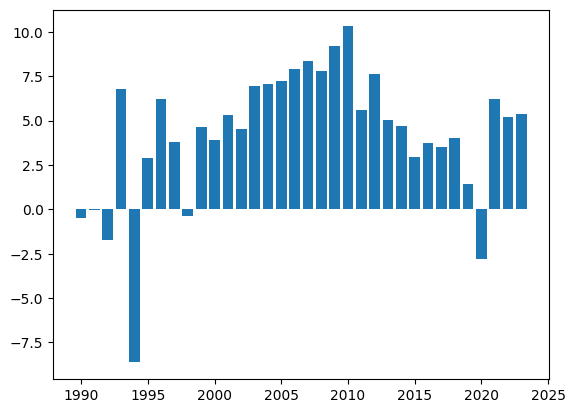